In [1]:
import os
import math
import numpy as np
import xarray as xr
import scipy.ndimage
from pathlib import Path
import netCDF4 as nc
import time
import sys
import multiprocessing
import json
import gc
import argparse

t=154800
t_new = 0
dilation_const = 1
max_entrainment_magnitude = 1e30

def dilate_mask(source, dilateAmount):
    if np.any(source) and dilateAmount > 0:

        expansion = np.zeros((3,3,3), dtype=bool)
        expansion[1, 1, :] = True  # X axis
        expansion[1, :, 1] = True  # Y axis
        expansion[:, 1, 1] = True  # Z axis

        for _ in range(dilateAmount):
            padded = np.pad(source, ((1, 1), (0, 0), (0, 0)), mode='constant', constant_values=False)
            padded = np.pad(padded, ((0, 0), (1, 1), (1, 1)), mode='wrap')
            dilated = scipy.ndimage.binary_dilation(padded, structure=expansion)
            unpadded_dilated = dilated[1:-1, 1:-1, 1:-1]
        return unpadded_dilated
    else:
        return source

In [32]:
source_input_dir = Path("/mnt/stor-pool-01/projects/heus/BNF/Ensemble_Tests/512_512_50m_12km_chbuff/2025-07-01_normal_shell/thijs")
output_dir = Path("/mnt/stor-pool-01/projects/heus/ShellAnalysis/SEUS")

paths = {
        "netE": source_input_dir / "netE.nc",
        "cloud_labels": output_dir / "cloud_labels.nc",
        "combined_labels": output_dir / "combined_labels.nc",
        "shell_labels": output_dir / "shell_labels.nc",
    }

In [33]:
with xr.open_dataset(paths["cloud_labels"], decode_times=False) as ds_cloud:
    cloud_labels = ds_cloud.cloud_labels.isel(time=t_new).values
    
with xr.open_dataset(paths["combined_labels"], decode_times=False) as ds_comb:
    combined_labels = ds_comb.labels.isel(time=t_new).values
    
with xr.open_dataset(paths["shell_labels"], decode_times=False) as ds_shell:
    shell_labels = ds_shell.shell_labels.isel(time=t_new).values

# pre-allocate sets
nz, ny, nx = cloud_labels.shape
out_shell_label_ent = np.zeros((nz, ny, nx), dtype=np.float32)
out_cloud_label_ent = np.zeros((nz, ny, nx), dtype=np.float32)
total_shell_ent_profile = np.zeros(nz, dtype=np.float32)
total_cloud_ent_profile = np.zeros(nz, dtype=np.float32)

with xr.open_dataset(paths["netE"], decode_times=False) as ds_e:
    # Helper inline function to slice and filter on the fly
    def load_and_filter(var_name):
        sliced = ds_e[var_name].sel(time=t)
        return xr.where(abs(sliced) < max_entrainment_magnitude, sliced, np.nan).values

    cloud_e_x = load_and_filter("netE_flux_x_ql")
    cloud_e_y = load_and_filter("netE_flux_y_ql")
    cloud_e_z = load_and_filter("netE_flux_z_ql")

    shell_e_x = load_and_filter("netE_flux_x_shell")
    shell_e_y = load_and_filter("netE_flux_y_shell")
    shell_e_z = load_and_filter("netE_flux_z_shell")

In [18]:
# ----------------------------------------------------------------------
# Step 1 - Shell Entrainment (Accumulates Shell Fluxes near Cloud Edges)
# ----------------------------------------------------------------------

# -- Iterate through shell
shell_list = np.unique(shell_labels)
shell_list = shell_list[shell_list != 0]

for label_i in shell_list:

    # obtain combined mask for that shell index
    label_mask = (combined_labels == label_i)

    # Iterate through each cloud
    contained_cloud_list = np.unique(cloud_labels[label_mask])
    contained_cloud_list = contained_cloud_list[contained_cloud_list != 0]

    if len(contained_cloud_list) == 0:
        print(f"Shell Label {label_i}: no clouds contained")
        continue

    combined_cloud_mask = np.isin(cloud_labels, contained_cloud_list)

    dilated_clouds = dilate_mask(combined_cloud_mask, dilation_const)

    if not np.any(dilated_clouds):
        continue

    e_x_mask = dilated_clouds | np.roll(dilated_clouds, shift=1, axis=2)
    e_y_mask = dilated_clouds | np.roll(dilated_clouds, shift=1, axis=1)
    e_z_mask = dilated_clouds | np.roll(dilated_clouds, shift=1, axis=0)
    e_z_mask[0, :, :] = dilated_clouds[0, :, :] # prevent rolling along boundary

    # sum x and y
    sum_x = np.nansum(shell_e_x * e_x_mask, axis=(1, 2))
    sum_y = np.nansum(shell_e_y * e_y_mask, axis=(1, 2))

    shell_target = (shell_labels == label_i)
    shell_above = shell_target
    shell_below = np.zeros_like(shell_target)
    shell_below[1:] = shell_target[:-1]

    case1_mask = e_z_mask & shell_above & ~shell_below # case 1: shell above but not below
    case2_mask = e_z_mask & shell_below & ~shell_above # case 2: shell below but not above

    # sum z
    sum_z_case1 = np.nansum(shell_e_z * case1_mask, axis=(1, 2))
    sum_z_case2 = np.nansum(shell_e_z * case2_mask, axis=(1, 2))

    sum_z = np.zeros(nz, dtype=np.float32)
    sum_z += sum_z_case1
    sum_z[:-1] += sum_z_case2[1:]  # Shift map back down safely

    # apply sums
    sum_total = (sum_x + sum_y + sum_z)
    broadcasted_sum = sum_total[:, np.newaxis, np.newaxis]

    out_shell_label_ent += broadcasted_sum * label_mask
    total_shell_ent_profile += sum_total

    print(f"Shell Label {label_i}:")
    print(f" -> Active flux cells in shell_e_x: {np.count_nonzero(shell_e_x != 0)}")
    print(f" -> Active cells in e_x_mask:       {np.count_nonzero(e_x_mask)}")
    print(f" -> Intersection non-zeros:         {np.count_nonzero((shell_e_x * e_x_mask) != 0)}")
    

# ----------------------------------------------------------------------
# Step 2 - Cloud Entrainment (Accumulates Cloud Fluxes near Shell Edges)
# ----------------------------------------------------------------------
cloud_list = np.unique(cloud_labels)
cloud_list = cloud_list[cloud_list != 0]

for c_label_i in cloud_list:
    cloud_target = (cloud_labels == c_label_i)

    # Finds the index of the very first True value in the cloud mask
    first_idx = np.argmax(cloud_target) 
    label_i = combined_labels.flat[first_idx]
    if label_i == 0:
        continue

    current_shell = (shell_labels == label_i)
    if not np.any(current_shell):
        continue

    dilated_shell = dilate_mask(current_shell, dilation_const)
    if not np.any(dilated_shell):
        continue

    e_x_mask = dilated_shell | np.roll(dilated_shell, shift=1, axis=2)
    e_y_mask = dilated_shell | np.roll(dilated_shell, shift=1, axis=1)
    e_z_mask = dilated_shell | np.roll(dilated_shell, shift=1, axis=0)
    e_z_mask[0, :, :] = dilated_shell[0, :, :] # prevent rolling along boundary

    # sum x,y
    sum_x = np.nansum(cloud_e_x * e_x_mask, axis=(1, 2))
    sum_y = np.nansum(cloud_e_y * e_y_mask, axis=(1, 2))

    cloud_above = cloud_target
    cloud_below = np.zeros_like(cloud_target)
    cloud_below[1:] = cloud_target[:-1]

    case1_mask = e_z_mask & cloud_above & ~cloud_below # case 1: shell above but not below
    case2_mask = e_z_mask & cloud_below & ~cloud_above # case 2: shell below but not above

    sum_z_case1 = np.nansum(cloud_e_z * case1_mask, axis=(1, 2))
    sum_z_case2 = np.nansum(cloud_e_z * case2_mask, axis=(1, 2))

    sum_z = np.zeros(nz, dtype=np.float32)
    sum_z += sum_z_case1
    sum_z[:-1] += sum_z_case2[1:]

    sum_total = (sum_x + sum_y + sum_z)
    broadcasted_sum = sum_total[:, np.newaxis, np.newaxis]

    out_cloud_label_ent += broadcasted_sum * cloud_target
    total_cloud_ent_profile += sum_total

Shell Label 1: no clouds contained
Shell Label 2: no clouds contained
Shell Label 3: no clouds contained
Shell Label 4: no clouds contained
Shell Label 5: no clouds contained
Shell Label 6: no clouds contained
Shell Label 7: no clouds contained
Shell Label 8: no clouds contained
Shell Label 9: no clouds contained
Shell Label 10: no clouds contained
Shell Label 11: no clouds contained
Shell Label 12: no clouds contained
Shell Label 13: no clouds contained
Shell Label 14: no clouds contained
Shell Label 15: no clouds contained
Shell Label 16: no clouds contained
Shell Label 17: no clouds contained
Shell Label 18: no clouds contained
Shell Label 19: no clouds contained
Shell Label 20: no clouds contained
Shell Label 21: no clouds contained
Shell Label 22: no clouds contained
Shell Label 23: no clouds contained
Shell Label 24: no clouds contained
Shell Label 25: no clouds contained
Shell Label 26: no clouds contained
Shell Label 27: no clouds contained
Shell Label 28: no clouds contained
S

In [5]:
np.unique(shell_e_x)

array([-9412.097, -9317.936, -9033.832, ..., 18168.3  , 18180.557,
             nan], dtype=float32)

In [6]:
sliced = ds_e["netE_flux_y_shell"].sel(time=154800)
np.unique(sliced)

array([-14889.848, -14841.085, -14798.278, ...,   8621.657,   8758.978,
              nan], dtype=float32)

In [14]:
np.unique(total_cloud_ent_profile)

array([0.], dtype=float32)

In [16]:
np.unique(out_shell_label_ent)

array([0.], dtype=float32)

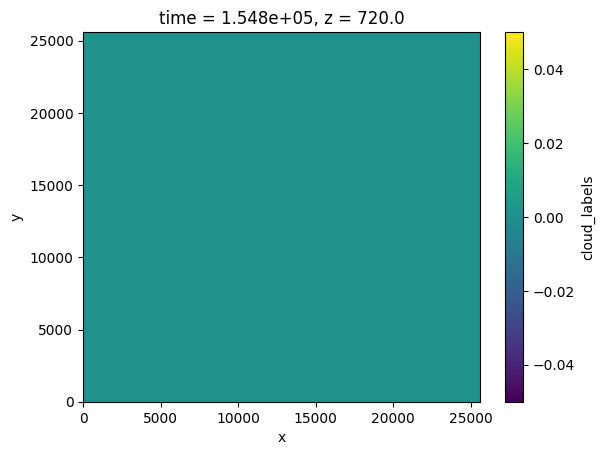

In [13]:
ds_cloud = xr.open_dataset(paths["cloud_labels"], decode_times=False)
ds_cloud.cloud_labels.isel(time=0, z=20).plot(x="x",y="y")

In [25]:
np.unique(ds_cloud.cloud_labels.isel(time=0).where(ds_comb.labels.isel(time=0) > 0).values)

array([ 0., nan])

In [20]:
np.unique(ds_shell.shell_labels.isel(time=0).values)

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

In [28]:
ds_cloud = xr.open_dataset(paths["cloud_labels"], decode_times=False)
ds_cloud.z

<xarray.DataArray 'z' (z: 159)> Size: 636B
array([1.0000e+01, 3.0000e+01, 5.2000e+01, 7.6000e+01, 1.0200e+02, 1.3100e+02,
       1.6300e+02, 2.0000e+02, 2.4000e+02, 2.8000e+02, 3.2000e+02, 3.6000e+02,
       4.0000e+02, 4.4000e+02, 4.8000e+02, 5.2000e+02, 5.6000e+02, 6.0000e+02,
       6.4000e+02, 6.8000e+02, 7.2000e+02, 7.6000e+02, 8.0000e+02, 8.4000e+02,
       8.8000e+02, 9.2000e+02, 9.6000e+02, 1.0000e+03, 1.0400e+03, 1.0800e+03,
       1.1200e+03, 1.1600e+03, 1.2000e+03, 1.2400e+03, 1.2800e+03, 1.3200e+03,
       1.3600e+03, 1.4000e+03, 1.4400e+03, 1.4800e+03, 1.5200e+03, 1.5600e+03,
       1.6000e+03, 1.6400e+03, 1.6800e+03, 1.7200e+03, 1.7600e+03, 1.8000e+03,
       1.8400e+03, 1.8800e+03, 1.9200e+03, 1.9600e+03, 2.0000e+03, 2.0400e+03,
       2.0800e+03, 2.1200e+03, 2.1600e+03, 2.2000e+03, 2.2400e+03, 2.2800e+03,
       2.3200e+03, 2.3600e+03, 2.4000e+03, 2.4400e+03, 2.4800e+03, 2.5200e+03,
       2.5600e+03, 2.6000e+03, 2.6400e+03, 2.6800e+03, 2.7200e+03, 2.7600e+03,
       2.8000e+03, 2.8400e+03, 2.8800e+03, 2.9200e+03, 2.9600e+03, 3.0000e+03,
       3.0400e+03, 3.0800e+03, 3.1200e+03, 3.1600e+03, 3.2000e+03, 3.2400e+03,
       3.2800e+03, 3.3200e+03, 3.3600e+03, 3.4000e+03, 3.4400e+03, 3.4800e+03,
       3.5200e+03, 3.5600e+03, 3.6000e+03, 3.6400e+03, 3.6800e+03, 3.7200e+03,
       3.7600e+03, 3.8000e+03, 3.8400e+03, 3.8800e+03, 3.9200e+03, 3.9600e+03,
       4.0000e+03, 4.0400e+03, 4.0800e+03, 4.1200e+03, 4.1600e+03, 4.2000e+03,
       4.2400e+03, 4.2800e+03, 4.3200e+03, 4.3600e+03, 4.4000e+03, 4.4400e+03,
       4.4800e+03, 4.5200e+03, 4.5600e+03, 4.6000e+03, 4.6400e+03, 4.6800e+03,
       4.7200e+03, 4.7600e+03, 4.8000e+03, 4.8400e+03, 4.8800e+03, 4.9200e+03,
       4.9600e+03, 5.0000e+03, 5.0400e+03, 5.0840e+03, 5.1320e+03, 5.1850e+03,
       5.2430e+03, 5.3070e+03, 5.3770e+03, 5.4540e+03, 5.5390e+03, 5.6320e+03,
       5.7340e+03, 5.8460e+03, 5.9690e+03, 6.1040e+03, 6.2530e+03, 6.4170e+03,
       6.5970e+03, 6.7950e+03, 7.0130e+03, 7.2530e+03, 7.5170e+03, 7.8070e+03,
       8.1260e+03, 8.4770e+03, 8.8630e+03, 9.2880e+03, 9.7550e+03, 1.0269e+04,
       1.0834e+04, 1.1455e+04, 1.2138e+04], dtype=float32)
Coordinates:
  * z        (z) float32 636B 10.0 30.0 52.0 ... 1.083e+04 1.146e+04 1.214e+04

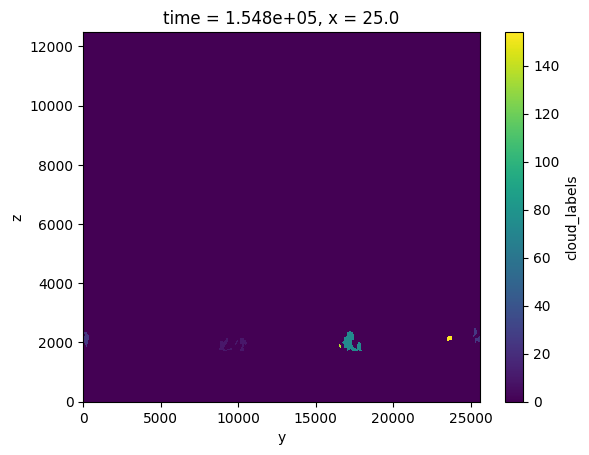

In [29]:
ds_cloud.isel(time=0,x=0).cloud_labels.plot(x="y",y="z")

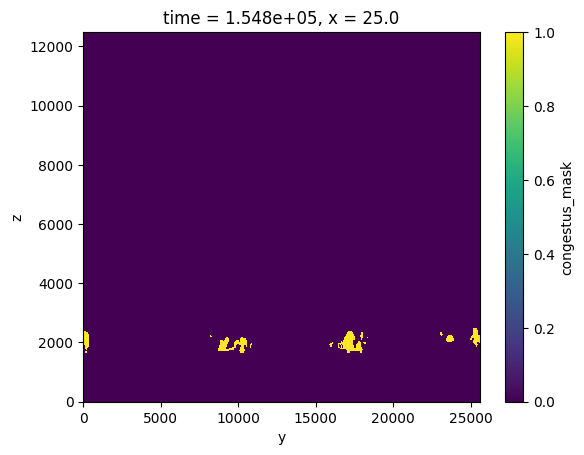

In [30]:
ds_test = xr.open_dataset(output_dir / "congestus_mask.nc", decode_times=False)
ds_test.isel(time=0,x=0).congestus_mask.plot(x="y",y="z")